# Arsenic Contamination scenario on Net1

In [1]:
import numpy as np
from epyt_flow.data.benchmarks import load_leakdb_scenarios
from epyt_flow.simulation import ScenarioSimulator, EpanetConstants, ScenarioConfig
from epyt_flow.simulation.events import SpeciesInjectionEvent
from epyt_flow.utils import to_seconds

Load a new scenario:

In [2]:
config, = load_leakdb_scenarios(scenarios_id=["1"], use_net1=True, verbose=False, download_dir="")
config = ScenarioConfig(scenario_config=config,
                        f_msx_in="arsenic_contamination.msx")

In [3]:
sim = ScenarioSimulator(scenario_config=config)

Explore network :

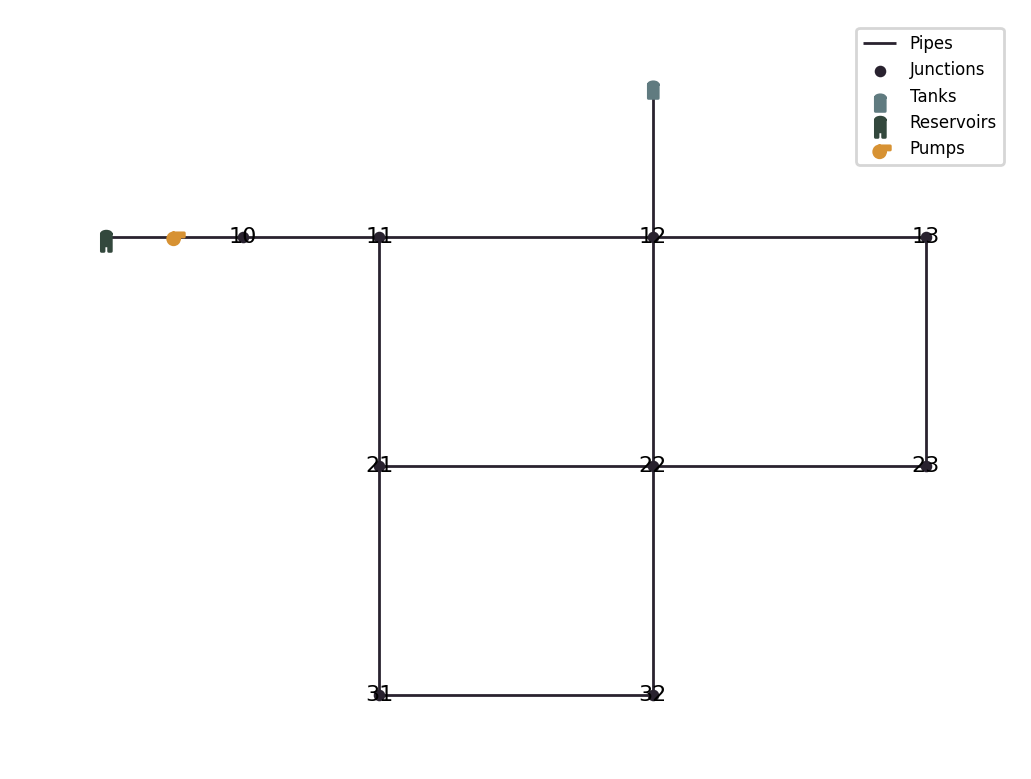

In [4]:
from epyt_flow.visualization import ScenarioVisualizer
vis = ScenarioVisualizer(sim)
vis.add_labels(["nodes"])
vis.show_plot()

In [5]:
topo = sim.get_topology()

print(topo.nodes)
print(topo.edges)


['10', '11', '12', '13', '21', '22', '23', '31', '32', '9', '2']
[('10', '11'), ('10', '9'), ('11', '12'), ('11', '21'), ('12', '13'), ('12', '2'), ('12', '22'), ('13', '23'), ('21', '22'), ('21', '31'), ('22', '23'), ('22', '32'), ('31', '32')]


In [6]:
# Show information associated with node "2"
print(topo.get_node_info("2"))

{'elevation': 259.0799865722656, 'coord': [50.0, 90.0], 'comment': '', 'type': 2, 'base_demand': 0.0, 'diameter': 15.392399787902832, 'max_level': 45.720001220703125, 'min_level': 30.479999542236328, 'min_vol': 5671.755859375, 'mixing_fraction': 1.0, 'mixing_model': 0, 'init_vol': 6806.10693359375, 'cylindric': True, 'can_overflow': False, 'vol_curve_id': ''}


Set simulation to 21 days :

In [7]:
sim.set_general_parameters(simulation_duration=to_seconds(days=21))

Place some chlorine sensors and also keep track of the contaminant:

In [8]:
cl_sensor_locations = ["10", "11", "12", "13", "21", "22", "23", "31", "32"]
all_nodes = sim.sensor_config.nodes

sim.set_bulk_species_node_sensors({"Chlorine": cl_sensor_locations,
                                   # Also: Keep track of the contaminant
                                   "AsIII": all_nodes})   # Arsenite

Creation of one contamination event

In [ ]:
import random

possible_nodes = ["22"] # possible nodes where the contamination can be injected

species = "AsIII" 
contamination_node = random.choice(possible_nodes) # choose a random node from the possible nodes for contamination injection
start_day = random.randint(3, 15)  # choose a random start day for the contamination event 
duration_days = random.randint(2, 5)  # choose a random duration for the contamination event in days
injection_amount = random.randint(1, 1000000) # choose a random injection amount for the contamination event
source_type = EpanetConstants.EN_MASS 


def generate_contamination_event(species: str, contamination_node: str, injection_amount: float, source_type: int, start_day: int, duration_days: int):
    """
    Function to generate a contamination event, which consists of an injection of a species at a node in the network.
    The contamination event is defined as an injection of a species at a specific node in the network, with a specified profile and duration.

    Parameters:
    species: id of the species being injected
    contamination_node: node id where the contamination occurs
    start_day: day of the start of the contamination event 
    duration_days: duration of the contamination event in days 
    injection_amount: amount of species injected 

    Returns:
    contamination_event: a SpeciesInjectionEvent object that represents the contamination event

    """
    
    contamination_event = SpeciesInjectionEvent(
        species_id=species,
        node_id=contamination_node,
        profile=np.array([injection_amount]),
        source_type=source_type,
        start_time=to_seconds(days=start_day),
        end_time=to_seconds(days=start_day + duration_days)
    )

    return contamination_event


event = generate_contamination_event(species, contamination_node, injection_amount, source_type, start_day, duration_days)
print(f"Generated contamination event: {event}")
sim.add_system_event(event)

Generated contamination event: start_time: 518400 end_time: 777600 species_id: AsIII node_id: 22 profile: [200130] source_type: 1


Run the entire simulation by calling [run_simulation()](https://epyt-flow.readthedocs.io/en/stable/epyt_flow.simulation.html#epyt_flow.simulation.scenario_simulator.ScenarioSimulator.run_simulation):

In [10]:
scada_data = sim.run_simulation()

c:\Users\eline\Documents\Documents\university\Master 2\memoire\AI-for-Drinking-Water\env\Lib\site-packages\epyt_flow\simulation\scenario_simulator.py:2978: UserWarning: Failed to remove temporary file 'C:\Users\eline\AppData\Local\Temp\epytflow_MSX_0d966517-0436-4fea-b844-50b384f360d3.hyd'
  warnings.warn(f"Failed to remove temporary file '{hyd_export}'")


Inspect simulation results:

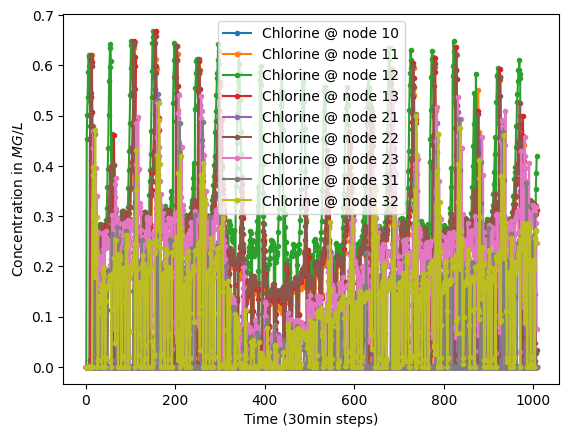

<Axes: xlabel='Time (30min steps)', ylabel='Concentration in $MG/L$'>

In [11]:
scada_data.plot_bulk_species_node_concentration({"Chlorine": cl_sensor_locations})

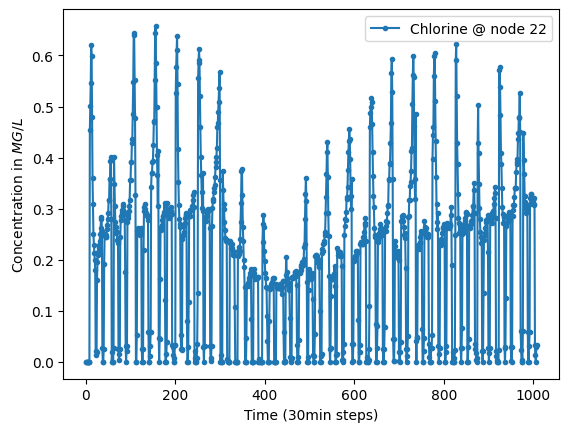

<Axes: xlabel='Time (30min steps)', ylabel='Concentration in $MG/L$'>

In [12]:
scada_data.plot_bulk_species_node_concentration({"Chlorine": ["22"]})

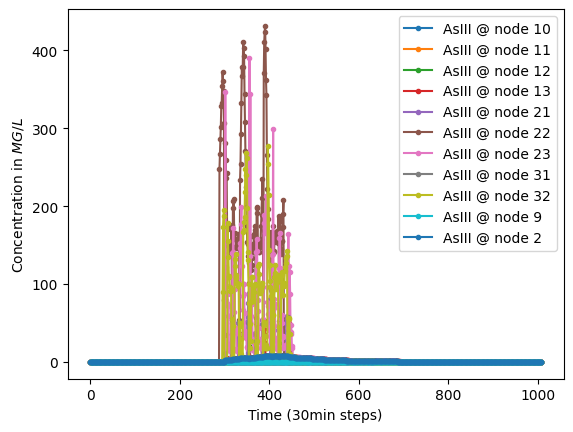

<Axes: xlabel='Time (30min steps)', ylabel='Concentration in $MG/L$'>

In [13]:
scada_data.plot_bulk_species_node_concentration({"AsIII": all_nodes})

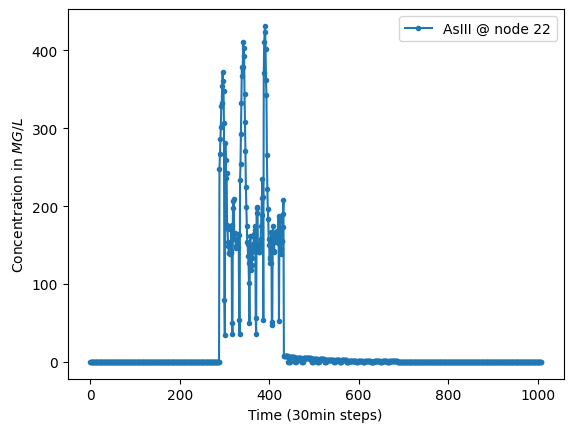

<Axes: xlabel='Time (30min steps)', ylabel='Concentration in $MG/L$'>

In [14]:
scada_data.plot_bulk_species_node_concentration({"AsIII": ["22"]})

Export results to csv

In [ ]:
# Export SCADA results 

df = scada_data.to_pandas_dataframe(export_raw_data=False)
df.to_csv("scada_data.csv", index=False)


Close the simulation :

In [16]:
sim.close()